# RAGAS Crash Course 📊
**Learn how to check if a RAG (search + AI answer) system is actually good.**

**Tools used:** Groq (a free AI model) + HuggingFace (free embeddings) + RAGAS + **LangGraph** (to build the pipeline itself)

**Get a free Groq key here:** https://console.groq.com

---
## What You'll Learn (Roadmap)
1. What RAGAS is, and why you need it
2. Install the tools
3. How RAGAS thinks about a RAG system (the big picture)
4. Build a small RAG pipeline with **LangGraph**
5. The format RAGAS wants your data in
6. Connect Groq + HuggingFace to RAGAS
7. Metrics for search (did we find the right information?)
8. Metrics for the AI's answer (did it answer well?)
9. Metrics for correctness (is the answer actually true?)
10. Run all the metrics together
11. Look at your results properly (not just the average)
12. Free metrics — no AI calls needed
13. Write your own custom metric
14. Compare two RAG systems and prove which one is better
15. Add an automatic pass/fail check (for CI)
16. Common mistakes, and how to fix them
17. Going Further — Bigger LangGraph Pipelines

**Demo app:** run `streamlit run ragas_eval_app.py` to try all of this with a simple UI.

---
## 1. What Is RAGAS?

RAGAS scores your RAG pipeline automatically, using an AI model as the judge — so you're not
reading every answer by hand.

A RAG system has 2 steps that can each fail independently:
1. **Search** — can retrieve the wrong (or incomplete) information.
2. **Answer** — the AI can ignore what it was given and make things up.

We'll cover the scores for each step starting in section 7.

---
## 2. Install & Setup

First, install the tools we need.

In [1]:
!pip install "ragas==0.3.9" langchain langchain-groq langchain-huggingface langgraph sentence-transformers datasets pandas matplotlib -q


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
from dotenv import load_dotenv

# Load .env
load_dotenv()

# Get Groq API key
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env file")

print("Groq API key loaded successfully!")


import pandas as pd

pd.set_option("display.max_colwidth", 120)


# Workaround for a known ragas bug
import sys
import types

try:
    import langchain_community.chat_models.vertexai  # noqa: F401
except ModuleNotFoundError:
    stub = types.ModuleType("langchain_community.chat_models.vertexai")
    stub.ChatVertexAI = type("ChatVertexAI", (), {})
    sys.modules["langchain_community.chat_models.vertexai"] = stub


print("Setup done!")

Groq API key loaded successfully!
Setup done!


C:\Users\Nidhi\AppData\Local\Temp\ipykernel_12580\3970941769.py:26: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  import langchain_community.chat_models.vertexai  # noqa: F401


---
## 3. How RAGAS Thinks (Big Picture)

```
Question → Search → Info Found → AI Model → Answer
```

RAGAS checks 3 things, in order:
1. Did search find good info?
2. Did the AI use that info correctly?
3. Is the final answer actually correct?

**Every RAGAS test case needs 4 things:**
- `user_input` — the question
- `retrieved_contexts` — the info search found
- `response` — the AI's answer
- `reference` — the correct answer (you write this yourself, ahead of time)

**One thing to remember:** Faithfulness and Response Relevancy don't need a `reference` — you
can use them anytime, even on real live answers. The other scores need you to already know the
correct answer.

---
## 4. Build a Small RAG Pipeline with LangGraph

Before we can use RAGAS, we need something to test. We'll build a very simple RAG pipeline:
a few facts about a made-up company, a search step, and Groq to write the answer — wired
together with **LangGraph**, not chained together by hand.

**Quick note on the imports below:** `ChatGroq` and `HuggingFaceEmbeddings` come from
`langchain_groq` / `langchain_huggingface` — small client libraries just for *talking* to Groq
and HuggingFace. LangGraph doesn't replace these; it uses them. LangGraph is the layer that
decides *what happens in what order* (search, then answer) — that orchestration is what this
section builds with `StateGraph`, not a plain Python function chain.

In [3]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
import numpy as np

llm = ChatGroq(model="openai/gpt-oss-120b", api_key=os.environ["GROQ_API_KEY"], temperature=0)
embedder = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

print("LLM + embedder ready")

c:\Users\Nidhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM + embedder ready


In [4]:
# Toy knowledge base — a fictional SaaS product, "Nimbus Cloud"
docs = [
    "Nimbus Cloud offers three pricing tiers: Starter ($9/mo), Pro ($29/mo), and Enterprise (custom pricing).",
    "The Starter tier includes 10GB storage, 1 user seat, and email support.",
    "The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.",
    "Enterprise customers get unlimited storage, SSO, a dedicated account manager, and a 99.9% uptime SLA.",
    "Nimbus Cloud was founded in 2021 and is headquartered in Austin, Texas.",
    "Data is encrypted at rest using AES-256 and in transit using TLS 1.3.",
    "Nimbus Cloud supports integrations with Slack, Google Drive, and Zapier.",
    "Free trials last 14 days and do not require a credit card.",
    "The API rate limit is 100 requests per minute on the Pro tier and 1,000 on Enterprise.",
    "Customers can cancel their subscription anytime from the billing settings page; refunds are prorated.",
]

doc_embeddings = np.array(embedder.embed_documents(docs))
print(f"Embedded {len(docs)} chunks, shape={doc_embeddings.shape}")

Embedded 10 chunks, shape=(10, 384)


In [ ]:
def cosine_sim(a, b):
    return (a @ b.T) / (np.linalg.norm(a, axis=-1, keepdims=True) * np.linalg.norm(b, axis=-1))

def retrieve(question, top_k=3):
    q_emb = np.array(embedder.embed_query(question))
    scores = cosine_sim(doc_embeddings, q_emb.reshape(1, -1)).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    return [docs[i] for i in top_idx]

def generate_answer(question, contexts):
    context_block = "\n".join(f"- {c}" for c in contexts)
    prompt = f"""Answer the question using ONLY the context below. Be concise.

Context:
{context_block}

Question: {question}
Answer:"""
    return llm.invoke(prompt).contentR

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

class RAGState(TypedDict):
    question: str
    top_k: int
    contexts: List[str]
    answer: str

def retrieve_node(state: RAGState) -> RAGState:
    return {**state, "contexts": retrieve(state["question"], top_k=state["top_k"])}

def generate_node(state: RAGState) -> RAGState:
    return {**state, "answer": generate_answer(state["question"], state["contexts"])}

graph = StateGraph(RAGState)
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)
graph.set_entry_point("retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)
rag_graph = graph.compile()

def rag_pipeline(question, top_k=3):
    """The rest of this notebook calls rag_pipeline(question) like a plain function —
    but under the hood, every call now runs through the LangGraph graph above."""
    final_state = rag_graph.invoke({"question": question, "top_k": top_k, "contexts": [], "answer": ""})
    return final_state["answer"], final_state["contexts"]

# Smoke test
answer, contexts = rag_pipeline("What does the Pro tier include?")
print("Answer:", answer)
print("\nContexts used:")
for c in contexts:
    print(" -", c)

Answer: The Pro tier includes 500 GB of storage, 10 user seats, priority support, and API access.

Contexts used:
 - The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.
 - Nimbus Cloud offers three pricing tiers: Starter ($9/mo), Pro ($29/mo), and Enterprise (custom pricing).
 - The API rate limit is 100 requests per minute on the Pro tier and 1,000 on Enterprise.


---
## 5. The Format RAGAS Wants Your Data In

RAGAS needs a list of test cases, each one called a `SingleTurnSample`. Every test case has a
question, the info that was found, the AI's answer, and the correct answer. All these test
cases together go into an `EvaluationDataset`.

Below, we ask 5 questions, get real answers from our RAG system, and pair each one with a
correct answer that we already know by hand.

In [24]:
from ragas import SingleTurnSample, EvaluationDataset

# Kept small on purpose — every extra question multiplies LLM calls across every
# evaluate() call below. 3 is enough to see how the metrics behave.
eval_questions = [
    {
        "question": "What does the Pro tier include?",
        "reference": "The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.",
    },
    {
        "question": "How is data protected at Nimbus Cloud?",
        "reference": "Data is encrypted at rest using AES-256 and in transit using TLS 1.3.",
    },
    {
        "question": "Do I need a credit card for the free trial?",
        "reference": "No, the 14-day free trial does not require a credit card.",
    },
]


---
## 6. Connect Groq + HuggingFace to RAGAS

By default, RAGAS expects you to use OpenAI. Since we're using free tools instead, we need to
tell RAGAS to use our Groq model and HuggingFace embeddings as the judge. This is the single
most common mistake when using RAGAS without an OpenAI key — don't skip this step.

In [8]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

ragas_llm = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(embedder)

# Free-tier APIs have a per-minute request limit. ragas defaults to 16 concurrent
# calls, which blows past that limit and silently turns failed rows into NaN.
# Keep concurrency low so retries actually have room to succeed.
run_config = RunConfig(max_workers=4, max_wait=90)

print("RAGAS judge configured with Groq + HuggingFace")

# Note: judge quality matters. Faithfulness/relevancy checks are themselves LLM calls —
# a weak judge model gives noisy scores. Prefer a bigger Groq model (e.g. openai/gpt-oss-120b)
# as the judge if your free-tier rate limits allow it, even if you generate answers with a smaller one.

RAGAS judge configured with Groq + HuggingFace


C:\Users\Nidhi\AppData\Local\Temp\ipykernel_12580\397202561.py:5: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(llm)
C:\Users\Nidhi\AppData\Local\Temp\ipykernel_12580\397202561.py:6: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(embedder)


---
## 7. Metrics for Search

These check the search step only — not what the AI did with it.

- **Context Precision** — of what we found, how much was actually useful? *(found 5, only 2 useful → low)*
- **Context Recall** — of what we needed, how much did we find? *(needed 3 facts, found 1 → low)*
- **Context Entity Recall** — did we find the key names/numbers/dates? *(missing "$29/month" → low)*

In [9]:
from ragas.metrics import LLMContextPrecisionWithReference, LLMContextRecall, ContextEntityRecall
from ragas import evaluate

retrieval_metrics = [
    LLMContextPrecisionWithReference(),
    LLMContextRecall(),
    ContextEntityRecall(),
]

retrieval_result = evaluate(
    run_config=run_config,
    dataset=eval_dataset,
    metrics=retrieval_metrics,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)
retrieval_result.to_pandas()[["user_input", "llm_context_precision_with_reference", "context_recall", "context_entity_recall"]]

Evaluating: 100%|██████████| 9/9 [01:31<00:00, 10.17s/it]


,user_input,llm_context_precision_with_reference,context_recall,context_entity_recall
0,What does the Pro tier include?,0.833333,1.0,1.0
1,How is data protected at Nimbus Cloud?,0.000000,0.0,0.0
2,Do I need a credit card for the free trial?,1.000000,1.0,0.0


---
## 8. Metrics for the AI's Answer

- **Faithfulness** — does the answer only say things that are actually in the retrieved docs?
  *(doc says "$29/month", AI adds "and a free T-shirt" → made up → low)*
- **Response Relevancy** — does the answer actually match the question asked?
  *("How much does Pro cost?" → "Pro launched in 2022" → true but off-topic → low)*

In [10]:
from ragas.metrics import Faithfulness, ResponseRelevancy

generation_metrics = [Faithfulness(), ResponseRelevancy(strictness=1)]

generation_result = evaluate(
    run_config=run_config,
    dataset=eval_dataset,
    metrics=generation_metrics,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)
generation_result.to_pandas()[["user_input", "response", "faithfulness", "answer_relevancy"]]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 6/6 [00:50<00:00,  8.36s/it]


,user_input,response,faithfulness,answer_relevancy
0,What does the Pro tier include?,"The Pro tier includes 500 GB of storage, 10 user seats, priority support, and API access.",1.0,1.000000
1,How is data protected at Nimbus Cloud?,The provided context does not include information about how data is protected at Nimbus Cloud.,1.0,0.000000
2,Do I need a credit card for the free trial?,"No, a credit card is not required for the free trial.",1.0,0.986392


**Try this:** ask something the knowledge base can't answer (e.g. "CEO's favorite color?") —
a good system says "I don't know"; if it invents an answer, Faithfulness should drop.

---
## 9. Metrics for Correctness

Compare the AI's answer directly against the correct answer you already know.

- **Factual Correctness** — do the facts match? *("$29/month" vs AI saying "$39/month" → wrong number → low)*
- **Semantic Similarity** — does it mean the same thing, even worded differently?
  *("$29/month" vs "twenty-nine dollars a month" → same meaning → high)*

In [11]:
from ragas.metrics import FactualCorrectness, SemanticSimilarity

correctness_metrics = [FactualCorrectness(), SemanticSimilarity()]

correctness_result = evaluate(
    run_config=run_config,
    dataset=eval_dataset,
    metrics=correctness_metrics,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)
correctness_result.to_pandas()[["user_input", "response", "reference", "factual_correctness(mode=f1)", "semantic_similarity"]]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 6/6 [01:16<00:00, 12.81s/it]


,user_input,response,reference,factual_correctness(mode=f1),semantic_similarity
0,What does the Pro tier include?,"The Pro tier includes 500 GB of storage, 10 user seats, priority support, and API access.","The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.",1.0,0.996061
1,How is data protected at Nimbus Cloud?,The provided context does not include information about how data is protected at Nimbus Cloud.,Data is encrypted at rest using AES-256 and in transit using TLS 1.3.,0.5,0.537527
2,Do I need a credit card for the free trial?,"No, a credit card is not required for the free trial.","No, the 14-day free trial does not require a credit card.",1.0,0.898977


---
## 10. Run All the Metrics Together

In real use, you don't run metrics one at a time — you run everything you care about in a
single call. RAGAS handles all the AI calls for you and gives back one combined result.

In [12]:
all_metrics = [
    LLMContextPrecisionWithReference(),
    LLMContextRecall(),
    ContextEntityRecall(),
    Faithfulness(),
    ResponseRelevancy(strictness=1),
    FactualCorrectness(),
    SemanticSimilarity(),
]

result = evaluate(
    run_config=run_config,
    dataset=eval_dataset,
    metrics=all_metrics,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

print(result)  # aggregate (mean) score per metric
df = result.to_pandas()
df

Evaluating:  19%|█▉        | 4/21 [00:54<03:27, 12.19s/it]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Nidhi\AppData\Local\Programs\Python\Python311\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x0000022927F2FF80> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-593' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Nidhi\AppData\Roaming\Python\Python311\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-594' coro=<Kernel.shell_main() running at C:\Users\Nidhi\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at c:\Users\Nidhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
c:\U

{'llm_context_precision_with_reference': 0.6667, 'context_recall': 0.6667, 'context_entity_recall': 0.3333, 'faithfulness': 1.0000, 'answer_relevancy': 0.6621, 'factual_correctness(mode=f1)': 0.7233, 'semantic_similarity': 0.8109}


,user_input,retrieved_contexts,response,reference,llm_context_precision_with_reference,context_recall,context_entity_recall,faithfulness,answer_relevancy,factual_correctness(mode=f1),semantic_similarity
0,What does the Pro tier include?,"[The Pro tier includes 500GB storage, 10 user seats, priority support, and API access., Nimbus Cloud offers three pr...","The Pro tier includes 500 GB of storage, 10 user seats, priority support, and API access.","The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.",1.0,1.0,1.0,1.0,1.000000,1.00,0.996061
1,How is data protected at Nimbus Cloud?,"[Nimbus Cloud supports integrations with Slack, Google Drive, and Zapier., Nimbus Cloud was founded in 2021 and is h...",The provided context does not include information about how data is protected at Nimbus Cloud.,Data is encrypted at rest using AES-256 and in transit using TLS 1.3.,0.0,0.0,0.0,1.0,0.000000,0.50,0.537527
2,Do I need a credit card for the free trial?,"[Free trials last 14 days and do not require a credit card., Customers can cancel their subscription anytime from th...","No, a credit card is not required for the free trial.","No, the 14-day free trial does not require a credit card.",1.0,1.0,0.0,1.0,0.986392,0.67,0.898977


---
## 11. Look at Your Results Properly (Not Just the Average)

An average score can hide real problems. Always check which specific questions scored low
before you trust the overall number.

In [13]:
score_cols = [c for c in df.columns if c not in
              ["user_input", "retrieved_contexts", "response", "reference"]]

print("Average scores:")
print(df[score_cols].mean().round(3))

print("\nWorst-scoring question per metric:")
for col in score_cols:
    if df[col].isna().all():
        print(f"  {col}: every row failed (NaN) — likely a rate limit, not a real score")
        continue
    worst_row = df.loc[df[col].idxmin()]
    print(f"  {col}: {worst_row['user_input']!r} -> {worst_row[col]:.3f}")

Average scores:
llm_context_precision_with_reference    0.667
context_recall                          0.667
context_entity_recall                   0.333
faithfulness                            1.000
answer_relevancy                        0.662
factual_correctness(mode=f1)            0.723
semantic_similarity                     0.811
dtype: float64

Worst-scoring question per metric:
  llm_context_precision_with_reference: 'How is data protected at Nimbus Cloud?' -> 0.000
  context_recall: 'How is data protected at Nimbus Cloud?' -> 0.000
  context_entity_recall: 'How is data protected at Nimbus Cloud?' -> 0.000
  faithfulness: 'What does the Pro tier include?' -> 1.000
  answer_relevancy: 'How is data protected at Nimbus Cloud?' -> 0.000
  factual_correctness(mode=f1): 'How is data protected at Nimbus Cloud?' -> 0.500
  semantic_similarity: 'How is data protected at Nimbus Cloud?' -> 0.538


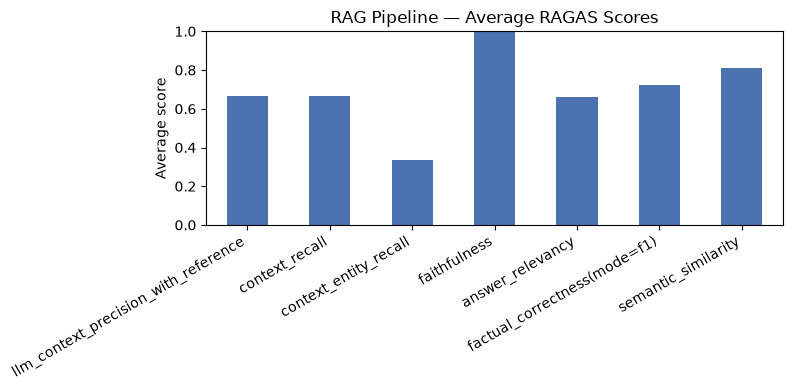

In [14]:
import matplotlib.pyplot as plt

means = df[score_cols].mean()
plt.figure(figsize=(8, 4))
means.plot(kind="bar", color="#4C72B0")
plt.ylabel("Average score")
plt.title("RAG Pipeline — Average RAGAS Scores")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [15]:
# Flag anything below a quality bar for manual review — this is the pattern you'd
# wire into a CI check or a dashboard alert.
THRESHOLD = 0.7
flagged = df[(df[score_cols] < THRESHOLD).any(axis=1)]
print(f"{len(flagged)}/{len(df)} samples fell below {THRESHOLD} on at least one metric")
flagged[["user_input"] + score_cols]

2/3 samples fell below 0.7 on at least one metric


,user_input,llm_context_precision_with_reference,context_recall,context_entity_recall,faithfulness,answer_relevancy,factual_correctness(mode=f1),semantic_similarity
1,How is data protected at Nimbus Cloud?,0.0,0.0,0.0,1.0,0.000000,0.50,0.537527
2,Do I need a credit card for the free trial?,1.0,1.0,0.0,1.0,0.986392,0.67,0.898977


---
## 12. Free Metrics (No AI Calls Needed)

Every metric so far uses an AI model to judge the answer — which costs money and takes time.
RAGAS also has plain text-comparison metrics that are free and instant. These are great as a
quick first check, before spending money on the AI-judged metrics.

| Metric | What it checks |
|---|---|
| `NonLLMStringSimilarity` | How similar are two pieces of text, character by character? |
| `BleuScore` | How many words/phrases overlap? (a metric originally built for translation) |
| `RougeScore` | A similar idea, focused on catching missed words |

In [16]:
from ragas.metrics import NonLLMStringSimilarity, BleuScore, RougeScore

free_metrics = [NonLLMStringSimilarity(), BleuScore(), RougeScore()]

free_result = evaluate(dataset=eval_dataset, metrics=free_metrics)  # no llm/embeddings needed
free_result.to_pandas()[["user_input", "response", "reference",
                          "non_llm_string_similarity", "bleu_score", "rouge_score(mode=fmeasure)"]]

Evaluating: 100%|██████████| 9/9 [00:00<00:00, 149.47it/s]


,user_input,response,reference,non_llm_string_similarity,bleu_score,rouge_score(mode=fmeasure)
0,What does the Pro tier include?,"The Pro tier includes 500 GB of storage, 10 user seats, priority support, and API access.","The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.",0.955056,0.748329,0.866667
1,How is data protected at Nimbus Cloud?,The provided context does not include information about how data is protected at Nimbus Cloud.,Data is encrypted at rest using AES-256 and in transit using TLS 1.3.,0.223404,0.032186,0.200000
2,Do I need a credit card for the free trial?,"No, a credit card is not required for the free trial.","No, the 14-day free trial does not require a credit card.",0.421053,0.158421,0.347826


**When to use these:** a correct answer can be worded in a completely different way and
still be right — these metrics will unfairly score that low. Use them as a fast, free check on
every code change, and save the AI-judged metrics (Faithfulness, Factual Correctness) for a
slower, more thorough test that runs less often.

---
## 13. Write Your Own Custom Metric

Sometimes the built-in metrics don't cover what you actually need. There are two ways to add
your own:

**A. `AspectCritic`** — describe a rule in plain English, and RAGAS uses an AI model to check
if the answer passes or fails. Good for simple rules like tone, safety, or formatting.

**B. A fully custom metric** — write real code when you need an exact check, like looking for a
number or a keyword, instead of asking an AI to judge it.

In [17]:
from ragas.metrics import AspectCritic

no_speculation = AspectCritic(
    name="no_speculation",
    definition=(
        "Return 1 if the answer states only facts present in the given context, "
        "with no speculation or invented details. Return 0 otherwise."
    ),
    llm=ragas_llm,
)

critic_result = evaluate(
    run_config=run_config,
    dataset=eval_dataset, metrics=[no_speculation])
critic_result.to_pandas()[["user_input", "response", "no_speculation"]]

Evaluating: 100%|██████████| 3/3 [00:01<00:00,  2.54it/s]


,user_input,response,no_speculation
0,What does the Pro tier include?,"The Pro tier includes 500 GB of storage, 10 user seats, priority support, and API access.",1
1,How is data protected at Nimbus Cloud?,The provided context does not include information about how data is protected at Nimbus Cloud.,1
2,Do I need a credit card for the free trial?,"No, a credit card is not required for the free trial.",1


In [18]:
from ragas.metrics.base import Metric
from ragas.dataset_schema import SingleTurnSample
import re

class MentionsPriceMetric(Metric):
    """Fully custom, code-based metric — no LLM call. Checks whether the answer
    cites a concrete dollar figure, useful here since our KB is pricing-heavy."""
    name = "mentions_price"

    def _score(self, row: SingleTurnSample) -> float:
        return 1.0 if re.search(r"\$\d", row.response) else 0.0

    async def _single_turn_ascore(self, sample: SingleTurnSample, callbacks=None) -> float:
        return self._score(sample)

# Quick manual check (custom code-based metrics are simplest to run directly, not via evaluate())
for s in eval_dataset.samples:
    has_price = 1.0 if re.search(r"\$\d", s.response) else 0.0
    print(f"{s.user_input[:50]:50s} -> mentions_price={has_price}")

What does the Pro tier include?                    -> mentions_price=0.0
How is data protected at Nimbus Cloud?             -> mentions_price=0.0
Do I need a credit card for the free trial?        -> mentions_price=0.0


---
## 14. Compare Two RAG Systems

This is the real reason to use RAGAS: proving that a change actually made things better, with
numbers instead of guessing. Let's compare `top_k=1` (fewer documents) against `top_k=3` (more
documents) on the exact same questions.

In [19]:
samples_k1 = []
for item in eval_questions:
    answer, contexts = rag_pipeline(item["question"], top_k=1)
    samples_k1.append(SingleTurnSample(
        user_input=item["question"],
        retrieved_contexts=contexts,
        response=answer,
        reference=item["reference"],
    ))
eval_dataset_k1 = EvaluationDataset(samples=samples_k1)

compare_metrics = [LLMContextRecall(), Faithfulness(), FactualCorrectness()]

result_k1 = evaluate(
    run_config=run_config,
    dataset=eval_dataset_k1, metrics=compare_metrics, llm=ragas_llm, embeddings=ragas_embeddings)
result_k3 = evaluate(
    run_config=run_config,
    dataset=eval_dataset, metrics=compare_metrics, llm=ragas_llm, embeddings=ragas_embeddings)

comparison = pd.DataFrame({
    "top_k=1": result_k1.to_pandas()[["context_recall", "faithfulness", "factual_correctness(mode=f1)"]].mean(),
    "top_k=3": result_k3.to_pandas()[["context_recall", "faithfulness", "factual_correctness(mode=f1)"]].mean(),
})
comparison["delta"] = comparison["top_k=3"] - comparison["top_k=1"]
comparison

Evaluating: 100%|██████████| 9/9 [01:56<00:00, 12.95s/it]


,top_k=1,top_k=3,delta
context_recall,0.666667,0.666667,0.0
faithfulness,1.000000,1.000000,0.0
factual_correctness(mode=f1),0.833333,0.833333,0.0


This is the pattern to use for *any* change you make — a different chunk size, a
different AI model, a different prompt, a different embedding model. Run both versions through
the same test questions, compare the scores, and keep the winner.

---
## 15. Add an Automatic Pass/Fail Check (CI)

Turn your evaluation into a simple pass/fail check. This can run automatically every time the
code changes, and stop a bad change from going live — the same idea as a normal test suite.

In [20]:
def regression_gate(eval_result, thresholds: dict):
    """Raise if any metric's mean score drops below its threshold."""
    scores = eval_result.to_pandas()
    failures = []
    for metric, min_score in thresholds.items():
        mean_score = scores[metric].mean()
        if mean_score < min_score:
            failures.append(f"{metric}: {mean_score:.3f} < required {min_score}")
    if failures:
        raise AssertionError("RAGAS regression gate FAILED:\n" + "\n".join(failures))
    print("RAGAS regression gate PASSED ✅")

thresholds = {"faithfulness": 0.8, "context_recall": 0.7, "factual_correctness(mode=f1)": 0.6}
try:
    regression_gate(result, thresholds)
except AssertionError as e:
    print(e)

# In a real CI pipeline: call this at the end of a pytest test, or as the last
# step of a GitHub Actions job — a non-zero exit / raised exception fails the build.

RAGAS regression gate FAILED:
context_recall: 0.667 < required 0.7


---
## 16. Common Mistakes, and How to Fix Them

| Problem | Likely reason | Fix |
|---|---|---|
| Every score shows up as `NaN` (missing) | You forgot to connect Groq/HuggingFace as the judge | Pass `llm=` and `embeddings=` into `evaluate()` (see section 6) |
| Faithfulness is low, but the answer looks fine to you | The answer says something true, but it wasn't actually in the documents you retrieved | Check `retrieved_contexts` — either the search missed the source, or the AI used its own outside knowledge |
| Context Recall is low, but Precision is high | Search is accurate, but not finding enough | Increase `top_k`, or fix your chunking so facts aren't split across pieces |
| Context Precision is low | `top_k` is too high, or chunks are too big and messy | Lower `top_k`, make chunks smaller, or try a better embedding model |
| Scores jump around a lot between runs | Too few test questions, or the judge model isn't set to `temperature=0` | Use more test questions, and set the judge model's `temperature=0` |
| Groq gives a rate-limit error mid-test | Free-plan limits, especially with many metrics × many questions | Test fewer things at once, add retries, or spread your calls out over time |
| Auto-generated questions are bad or too easy | You skipped reviewing them | Always read through generated questions by hand before using them (see section 13) |

**Golden rule:** never trust just the overall average score. Always look at a few actual
question / answer / document rows behind a low score, so you understand *why* it's low.

---
## 17. Going Further — Bigger LangGraph Pipelines

The pipeline from section 4 has 2 steps: search, then answer. Real pipelines are often bigger —
for example, rewriting the question first so search works better. Let's add that as a third
step, and notice that RAGAS still needs zero changes.

In [21]:
def rewrite_node(state: RAGState) -> RAGState:
    prompt = (
        "Rewrite this question to be clearer and more specific for a search engine. "
        f"Only output the rewritten question, nothing else.\n\nQuestion: {state['question']}"
    )
    rewritten = llm.invoke(prompt).content.strip()
    return {**state, "question": rewritten}

graph_v2 = StateGraph(RAGState)
graph_v2.add_node("rewrite", rewrite_node)
graph_v2.add_node("retrieve", retrieve_node)
graph_v2.add_node("generate", generate_node)
graph_v2.set_entry_point("rewrite")
graph_v2.add_edge("rewrite", "retrieve")
graph_v2.add_edge("retrieve", "generate")
graph_v2.add_edge("generate", END)
rag_graph_v2 = graph_v2.compile()

final_state = rag_graph_v2.invoke({"question": "pro tier stuff?", "top_k": 3, "contexts": [], "answer": ""})
print("Answer:", final_state["answer"])
print("Contexts used:", final_state["contexts"])

Answer: The Pro tier provides 500 GB of storage, 10 user seats, priority support, and API access.
Contexts used: ['The Pro tier includes 500GB storage, 10 user seats, priority support, and API access.', 'Nimbus Cloud offers three pricing tiers: Starter ($9/mo), Pro ($29/mo), and Enterprise (custom pricing).', 'The Starter tier includes 10GB storage, 1 user seat, and email support.']


**Try this yourself:** you already know how to score and compare two pipelines — that's
exactly what section 15 did. Build an `EvaluationDataset` from `rag_graph_v2` the same way,
run `evaluate()`, and compare its `context_recall` / `faithfulness` against the base pipeline
from section 4. Does rewriting the question actually help retrieval, or not? Only the scores
can tell you.

**For pipelines with multiple conversation turns or tool calls** (not just search → answer),
RAGAS has `MultiTurnSample` instead of `SingleTurnSample` — it stores a whole back-and-forth as
a list of turns. Same idea as everything above: pull the full history out of your graph's
state, and hand it to RAGAS. Metrics like `ToolCallAccuracy`, `TopicAdherence`, and
`AgentGoalAccuracy` are built for exactly that case.